<a href="https://colab.research.google.com/github/fpellerano/devllm/blob/main/20_3_b_Chunking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To upload a `requirements.txt` file to your Google Colab environment, follow these steps:

1.  **Open the Files pane**: Click the **Folder icon** in the left-hand sidebar.
2.  **Upload your file**:
    *   **Drag and drop** your file directly into the pane.
    *   **OR** click the **Upload to session storage** icon (a file with an upward arrow) to select it from your local machine.

  
>[IMPORTANT] Files uploaded this way are temporary and will be deleted once the session is recycled.

# Chunking Strategies for RAG

Before text can be stored in a vector database and retrieved, it must be split into **chunks** —
smaller, self-contained pieces of text that get individually embedded and indexed.

Chunking is one of the highest-leverage decisions in a RAG pipeline. Get it wrong and
even a great embedding model won't save you.

This notebook covers four strategies, from simple to sophisticated:
- **Character Text Splitter** — fixed-size splitting, the baseline
- **Recursive Character Text Splitter** — structure-aware, the most widely used in practice
- **Semantic Chunker** — embedding-based, splits on meaning shifts
- **LLM-based Chunker** — uses a language model to identify coherent segments

## Why Chunking Matters

Two fundamental constraints drive the need for chunking:

**1. Context window limits**
LLMs can only process a fixed number of tokens at once. You can't feed an entire book
into a prompt — you need to retrieve and inject only the relevant pieces.

**2. Retrieval precision**
When you embed a large document as a single vector, the embedding averages over all the
topics it covers. A question about one specific fact will retrieve the whole document,
which dilutes relevance. Smaller, focused chunks produce more precise embeddings.

### The Fundamental Tradeoff

| Chunk size | Pros | Cons |
|---|---|---|
| **Too small** (< 100 chars) | Very precise embeddings | Loses context, fragments sentences |
| **Too large** (> 2000 chars) | Rich context | Imprecise retrieval, high token cost |
| **Just right** (200–800 chars) | Balanced precision and context | Depends on content type |

There is no universal "right" chunk size — it depends on your documents, your queries,
and your embedding model. Experimentation is necessary.

### Chunk Overlap

Adjacent chunks often discuss related ideas. If you split exactly at a boundary,
a sentence that spans two chunks may become unreadable in isolation.

**Overlap** solves this: the end of chunk N is repeated at the start of chunk N+1,
ensuring that no information is stranded at a boundary. Typical overlap values are
10–20% of the chunk size.

In [ ]:
!pip install -qU -r requirements.txt

In [ ]:
from google.colab import userdata
import os

google_api_key = userdata.get("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = google_api_key

## Source Text

We will use the same text throughout this notebook so the outputs of each chunking
strategy are directly comparable. The text is an excerpt from the original
**RAG paper** (Lewis et al., 2020) — appropriate for a notebook about RAG pipelines.

In [ ]:
rag_paper_text = """Prior work on general-purpose architectures for NLP tasks has shown great
success without the use of retrieval. A single, pre-trained language model has been shown to
achieve strong performance on various classification tasks in the GLUE benchmarks after
fine-tuning. GPT-2 later showed that a single, left-to-right, pre-trained language model could
achieve strong performance across both discriminative and generative tasks. For further
improvement, BART and T5 propose a single, pre-trained encoder-decoder model that leverages
bi-directional attention to achieve stronger performance on discriminative and generative tasks.
Our work aims to expand the space of possible tasks with a single, unified architecture, by
learning a retrieval module to augment pre-trained, generative language models.

Learned Retrieval: There is significant work on learning to retrieve documents in information
retrieval, more recently with pre-trained, neural language models similar to ours. Some work
optimizes the retrieval module to aid in a specific, downstream task such as question answering,
using search, reinforcement learning, or a latent variable approach as in our work. These
successes leverage different retrieval-based architectures and optimization techniques to achieve
strong performance on a single task, while we show that a single retrieval-based architecture
can be fine-tuned for strong performance on a variety of tasks.

Memory-based Architectures: Our document index can be seen as a large external memory for
neural networks to attend to, analogous to memory networks. A key feature of our memory is
that it is comprised of raw text rather than distributed representations, which makes the
memory both human-readable, lending a form of interpretability to our model, and
human-writable, enabling us to dynamically update the model's memory by editing the document
index.

Retrieve-and-Edit Approaches: Our method shares some similarities with retrieve-and-edit
style approaches, where a similar training input-output pair is retrieved for a given input
and then edited to provide a final output. These approaches have proved successful in Machine
Translation and Semantic Parsing. Our approach differs in that it aggregates content from
several pieces of retrieved content rather than lightly editing a single retrieved item.

Discussion: In this work, we presented hybrid generation models with access to parametric and
non-parametric memory. We showed that our RAG models obtain state-of-the-art results on
open-domain QA. We found that people prefer RAG's generation over purely parametric models,
finding it more factual and specific. We illustrated how the retrieval index can be hot-swapped
to update the model without requiring any retraining. Our work opens new research directions on
how parametric and non-parametric memories interact and how to most effectively combine them."""

print(f"Text length : {len(rag_paper_text):,} characters")
print(f"Word count  : {len(rag_paper_text.split()):,} words")
print(f"\nPreview:\n{rag_paper_text[:200]}...")

Text length : 2,898 characters
Word count  : 416 words

Preview:
Prior work on general-purpose architectures for NLP tasks has shown great
success without the use of retrieval. A single, pre-trained language model has been shown to
achieve strong performance on var...


## 1. Character Text Splitter

The simplest strategy: split the text whenever a given separator is found,
keeping chunks at or below a specified character count.

Key parameters:
- **`chunk_size`**: maximum number of characters per chunk
- **`chunk_overlap`**: how many characters from the end of one chunk are repeated at the start of the next
- **`separator`**: the character(s) to split on (default: `\n\n`)

This splitter is format-agnostic and predictable, but it knows nothing about sentence
or paragraph boundaries — it will split mid-sentence if the character count demands it.

In [ ]:
from langchain_text_splitters import CharacterTextSplitter

splitter = CharacterTextSplitter(
    separator="\n\n",     # split on paragraph breaks first
    chunk_size=400,
    chunk_overlap=60,
    is_separator_regex=False,
)

chunks = splitter.create_documents([rag_paper_text])

print(f"chunk_size=400, chunk_overlap=60")
print(f"Chunks produced : {len(chunks)}")
print(f"Avg chunk length: {sum(len(c.page_content) for c in chunks) / len(chunks):.0f} chars\n")

for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i+1} ({len(chunk.page_content)} chars) ---")
    print(chunk.page_content[:120] + ("..." if len(chunk.page_content) > 120 else ""))
    print()

chunk_size=400, chunk_overlap=60
Chunks produced : 5
Avg chunk length: 578 chars

--- Chunk 1 (798 chars) ---
Prior work on general-purpose architectures for NLP tasks has shown great
success without the use of retrieval. A single...

--- Chunk 2 (629 chars) ---
Learned Retrieval: There is significant work on learning to retrieve documents in information
retrieval, more recently w...

--- Chunk 3 (451 chars) ---
Memory-based Architectures: Our document index can be seen as a large external memory for
neural networks to attend to, ...

--- Chunk 4 (453 chars) ---
Retrieve-and-Edit Approaches: Our method shares some similarities with retrieve-and-edit
style approaches, where a simil...

--- Chunk 5 (559 chars) ---
Discussion: In this work, we presented hybrid generation models with access to parametric and
non-parametric memory. We ...



### Chunk Size Experiment

How does `chunk_size` affect the number of chunks and their average length?
A larger chunk size means fewer, longer chunks; a smaller size means more, shorter chunks.
The relationship is roughly inverse — but not perfectly so, because the splitter always
tries to split at the separator and may produce chunks smaller than `chunk_size`.

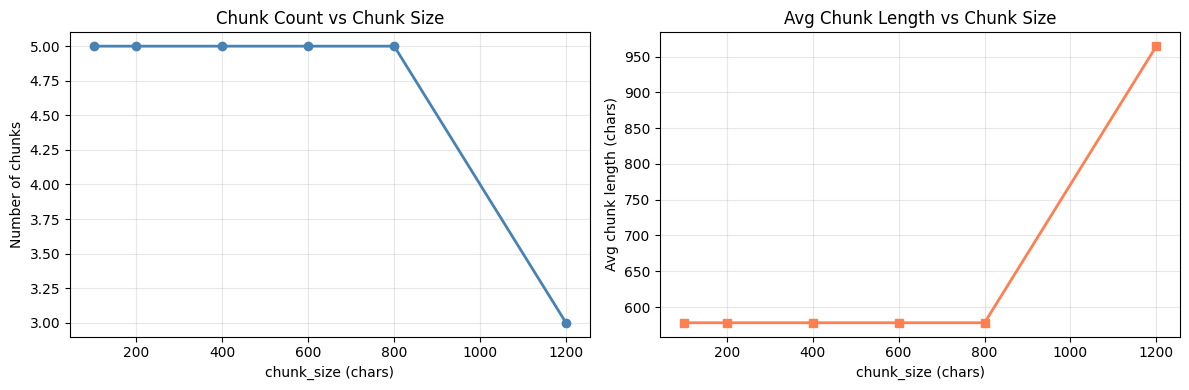

  chunk_size | # chunks | avg length
--------------------------------------
         100 |        5 |        578
         200 |        5 |        578
         400 |        5 |        578
         600 |        5 |        578
         800 |        5 |        578
        1200 |        3 |        965


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

chunk_sizes = [100, 200, 400, 600, 800, 1200]
overlap      = 50

counts       = []
avg_lengths  = []

for size in chunk_sizes:
    sp = CharacterTextSplitter(
        separator="\n\n",
        chunk_size=size,
        chunk_overlap=overlap,
        is_separator_regex=False,
    )
    ch = sp.create_documents([rag_paper_text])
    counts.append(len(ch))
    avg_lengths.append(sum(len(c.page_content) for c in ch) / len(ch))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(chunk_sizes, counts, marker="o", color="steelblue", linewidth=2)
ax1.set_xlabel("chunk_size (chars)")
ax1.set_ylabel("Number of chunks")
ax1.set_title("Chunk Count vs Chunk Size")
ax1.grid(True, alpha=0.3)

ax2.plot(chunk_sizes, avg_lengths, marker="s", color="coral", linewidth=2)
ax2.set_xlabel("chunk_size (chars)")
ax2.set_ylabel("Avg chunk length (chars)")
ax2.set_title("Avg Chunk Length vs Chunk Size")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'chunk_size':>12} | {'# chunks':>8} | {'avg length':>10}")
print("-" * 38)
for s, c, a in zip(chunk_sizes, counts, avg_lengths):
    print(f"{s:>12} | {c:>8} | {a:>10.0f}")

### The Role of Overlap

Without overlap, the boundary between two chunks can cut a sentence or idea in half.
The chunk on one side lacks the beginning, the chunk on the other lacks the ending —
both become harder to interpret in isolation.

With overlap, the shared text at boundaries gives each chunk the context it needs.

In [ ]:
# Same splitter, overlap=0 vs overlap=80 — compare the boundary region
boundary_text = (
    "The embedding model maps each sentence to a dense vector. "
    "Vectors that are semantically similar will cluster together in the high-dimensional space. "
    "This property is what enables similarity search to work: given a query vector, "
    "we find the nearest document vectors and retrieve their corresponding text."
)

for overlap_val in [0, 80]:
    sp = CharacterTextSplitter(separator=". ", chunk_size=120, chunk_overlap=overlap_val)
    ch = sp.create_documents([boundary_text])
    print(f"=== overlap={overlap_val} | {len(ch)} chunks ===")
    for i, c in enumerate(ch):
        print(f"  Chunk {i+1}: {c.page_content}")
    print()

=== overlap=0 | 3 chunks ===
  Chunk 1: The embedding model maps each sentence to a dense vector
  Chunk 2: Vectors that are semantically similar will cluster together in the high-dimensional space
  Chunk 3: This property is what enables similarity search to work: given a query vector, we find the nearest document vectors and retrieve their corresponding text.

=== overlap=80 | 3 chunks ===
  Chunk 1: The embedding model maps each sentence to a dense vector
  Chunk 2: Vectors that are semantically similar will cluster together in the high-dimensional space
  Chunk 3: This property is what enables similarity search to work: given a query vector, we find the nearest document vectors and retrieve their corresponding text.



## 2. Recursive Character Text Splitter

The most widely used splitter in practice. Instead of a single separator, it uses
an **ordered list of separators** and tries them from most to least structural:

```
["\n\n", "\n", ". ", " ", ""]
```

The algorithm works like this:
1. Try splitting on `\n\n` (paragraph breaks) — if all resulting chunks fit within `chunk_size`, done.
2. If any chunk is still too large, split it further using `\n` (line breaks).
3. Keep falling back through the separator list until chunks fit.
4. The last resort (`""`) splits character by character — a chunk will always fit eventually.

This means the splitter **respects natural text structure as much as possible**,
only going to finer-grained splits when forced to by the size constraint.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=60,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks = recursive_splitter.create_documents([rag_paper_text])

print(f"Recursive splitter | chunk_size=400, chunk_overlap=60")
print(f"Chunks produced : {len(chunks)}")
print(f"Avg chunk length: {sum(len(c.page_content) for c in chunks) / len(chunks):.0f} chars\n")

for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i+1} ({len(chunk.page_content)} chars) ---")
    print(chunk.page_content[:150] + ("..." if len(chunk.page_content) > 150 else ""))
    print()

Recursive splitter | chunk_size=400, chunk_overlap=60
Chunks produced : 11
Avg chunk length: 262 chars

--- Chunk 1 (349 chars) ---
Prior work on general-purpose architectures for NLP tasks has shown great
success without the use of retrieval. A single, pre-trained language model h...

--- Chunk 2 (368 chars) ---
achieve strong performance across both discriminative and generative tasks. For further
improvement, BART and T5 propose a single, pre-trained encoder...

--- Chunk 3 (79 chars) ---
learning a retrieval module to augment pre-trained, generative language models.

--- Chunk 4 (373 chars) ---
Learned Retrieval: There is significant work on learning to retrieve documents in information
retrieval, more recently with pre-trained, neural langua...

--- Chunk 5 (255 chars) ---
successes leverage different retrieval-based architectures and optimization techniques to achieve
strong performance on a single task, while we show t...

--- Chunk 6 (351 chars) ---
Memory-based Architectures: 

### Custom Separators for Structured Documents

The recursive splitter really shines when you customize the separator list to match
your document format. For transcripts, slide decks, or code files, you can define
separators that align with the document's own structure.

In [ ]:
# A podcast transcript with timestamps and section headers
transcript = """
[00:00] INTRODUCTION
Welcome to the course on LLM-powered applications. Today we explore retrieval-augmented generation
and why it dramatically reduces hallucinations in production systems.

[00:42] SECTION 1: WHAT IS RAG?
RAG combines a retriever — which finds relevant documents — with a generator that synthesizes
answers from them. Instead of relying solely on knowledge baked into model weights, RAG
grounds responses in retrieved evidence.

[02:10] SECTION 2: WHY CHUNKING MATTERS
The retriever works at the chunk level, not the document level. A good chunking strategy ensures
that each chunk is semantically self-contained. Poor chunking fragments ideas and degrades
retrieval precision, regardless of how good your embedding model is.

[04:55] SECTION 3: CHOOSING A STRATEGY
For plain prose, RecursiveCharacterTextSplitter is the default choice.
For code, use language-specific splitters. For documents with rich structure (PDFs, slides),
consider semantic or LLM-based chunking.

[06:30] CONCLUSION
The right chunking strategy depends on your content type and query patterns. Always evaluate
retrieval quality on a sample of real queries before choosing a production strategy.
"""

transcript_splitter = RecursiveCharacterTextSplitter(
    chunk_size=350,
    chunk_overlap=40,
    separators=[
        r"\[\d{2}:\d{2}\]",    # timestamps like [00:42]
        r"SECTION\s+\d+:",       # section headers
        "\n\n",                  # paragraph breaks
        ". ",                      # sentence boundaries
        " ",                       # words
    ],
    is_separator_regex=True,
)

chunks = transcript_splitter.create_documents([transcript])
print(f"Transcript chunks: {len(chunks)}\n")
for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i+1} ---")
    print(chunk.page_content.strip())
    print()

Transcript chunks: 5

--- Chunk 1 ---
[00:00] INTRODUCTION
Welcome to the course on LLM-powered applications. Today we explore retrieval-augmented generation
and why it dramatically reduces hallucinations in production systems.

--- Chunk 2 ---
[00:42] SECTION 1: WHAT IS RAG?
RAG combines a retriever — which finds relevant documents — with a generator that synthesizes
answers from them. Instead of relying solely on knowledge baked into model weights, RAG
grounds responses in retrieved evidence.

--- Chunk 3 ---
[02:10] SECTION 2: WHY CHUNKING MATTERS
The retriever works at the chunk level, not the document level. A good chunking strategy ensures
that each chunk is semantically self-contained. Poor chunking fragments ideas and degrades
retrieval precision, regardless of how good your embedding model is.

--- Chunk 4 ---
[04:55] SECTION 3: CHOOSING A STRATEGY
For plain prose, RecursiveCharacterTextSplitter is the default choice.
For code, use language-specific splitters. For documents wi

## 3. Semantic Chunker

Character-based splitters are oblivious to meaning — they split whenever the character
count is reached, regardless of whether that breaks a coherent thought.

The **Semantic Chunker** takes a different approach: it embeds consecutive sentences,
measures the cosine similarity between adjacent pairs, and inserts a chunk boundary
wherever the similarity drops sharply — indicating a **topic shift**.

This produces chunks that are coherent units of meaning, not arbitrary character windows.
The tradeoff: it requires an embedding model call for every sentence, making it slower
and more expensive than character-based splitting.

In [ ]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-2-preview",
    google_api_key=google_api_key,
)

# breakpoint_threshold_type controls how sensitive the splitter is to topic shifts:
# "percentile" (default): split at the Nth percentile of similarity drops
# "standard_deviation": split where similarity drops more than N std devs from mean
semantic_splitter = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=85,   # split at the top 15% sharpest topic shifts
)

In [ ]:
# The jellyfish text is a good test case: it has two distinct subtopics
# (taxonomy/biology and transdifferentiation) that the semantic splitter should detect
jellyfish_text = (
    "Turritopsis dohrnii, also known as the immortal jellyfish, is a species of small, "
    "biologically immortal jellyfish found worldwide in temperate to tropic waters. "
    "It is one of the few known cases of animals capable of reverting completely to a sexually "
    "immature, colonial stage after having reached sexual maturity as a solitary individual. "
    "Like most other hydrozoans, T. dohrnii begin their lives as tiny, free-swimming larvae "
    "known as planulae. As a planula settles down, it gives rise to a colony of polyps attached "
    "to the sea floor. All polyps and jellyfish arising from a single planula are genetically "
    "identical clones. Jellyfish then bud off these polyps and continue their life in a "
    "free-swimming form, eventually becoming sexually mature. "
    "If the T. dohrnii jellyfish is exposed to environmental stress, physical assault, "
    "or is sick or old, it can revert to the polyp stage, forming a new polyp colony. "
    "It does this through the cell development process of transdifferentiation, which alters "
    "the differentiated state of the cells and transforms them into new types of cells. "
    "Transdifferentiation is extremely rare in nature. Unlike regeneration, which repairs "
    "damaged tissue, transdifferentiation converts one mature cell type into another entirely. "
    "This process is what makes T. dohrnii biologically unique and of great interest to "
    "researchers studying aging and cellular reprogramming."
)

chunks = semantic_splitter.create_documents([jellyfish_text])

print(f"Semantic chunker produced {len(chunks)} chunk(s)\n")
for i, chunk in enumerate(chunks):
    print(f"=== Chunk {i+1} ({len(chunk.page_content)} chars) ===")
    print(chunk.page_content)
    print()

Semantic chunker produced 3 chunk(s)

=== Chunk 1 (745 chars) ===
Turritopsis dohrnii, also known as the immortal jellyfish, is a species of small, biologically immortal jellyfish found worldwide in temperate to tropic waters. It is one of the few known cases of animals capable of reverting completely to a sexually immature, colonial stage after having reached sexual maturity as a solitary individual. Like most other hydrozoans, T. dohrnii begin their lives as tiny, free-swimming larvae known as planulae. As a planula settles down, it gives rise to a colony of polyps attached to the sea floor. All polyps and jellyfish arising from a single planula are genetically identical clones. Jellyfish then bud off these polyps and continue their life in a free-swimming form, eventually becoming sexually mature.

=== Chunk 2 (333 chars) ===
If the T. dohrnii jellyfish is exposed to environmental stress, physical assault, or is sick or old, it can revert to the polyp stage, forming a new polyp colo

In [ ]:
# Apply the semantic splitter to the RAG paper text for comparison
chunks_semantic = semantic_splitter.create_documents([rag_paper_text])
print(f"RAG paper text: {len(chunks_semantic)} semantic chunk(s)\n")
for i, chunk in enumerate(chunks_semantic):
    print(f"--- Chunk {i+1} ({len(chunk.page_content)} chars) ---")
    print(chunk.page_content[:160] + ("..." if len(chunk.page_content) > 160 else ""))
    print()

RAG paper text: 4 semantic chunk(s)

--- Chunk 1 (267 chars) ---
Prior work on general-purpose architectures for NLP tasks has shown great
success without the use of retrieval. A single, pre-trained language model has been sh...

--- Chunk 2 (1836 chars) ---
GPT-2 later showed that a single, left-to-right, pre-trained language model could
achieve strong performance across both discriminative and generative tasks. Fo...

--- Chunk 3 (84 chars) ---
These approaches have proved successful in Machine
Translation and Semantic Parsing.

--- Chunk 4 (704 chars) ---
Our approach differs in that it aggregates content from
several pieces of retrieved content rather than lightly editing a single retrieved item. Discussion: In ...



## 4. Statistical Semantic Chunker

The `semantic-chunkers` library provides a **StatisticalChunker** that uses a HuggingFace
encoder (no API calls needed) to detect topic shifts. It works similarly to the
`SemanticChunker` above, but uses statistical thresholding over the similarity distribution
to decide where to split — making it more robust to noisy text.

In [ ]:
from semantic_chunkers import StatisticalChunker
from semantic_router.encoders import HuggingFaceEncoder

encoder = HuggingFaceEncoder(name="sentence-transformers/all-MiniLM-L6-v2")
stat_chunker = StatisticalChunker(encoder=encoder)

stat_chunks = stat_chunker(docs=[rag_paper_text])
stat_chunker.print(stat_chunks[0])

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-19 02:36:32 INFO semantic_chunkers.utils.logger Single document exceeds the maximum token limit of 300. Splitting to sentences before semantically merging.


  0%|          | 0/1 [00:00<?, ?it/s]

Split 1, tokens 294, triggered by: token limit
Prior work on general-purpose architectures for NLP tasks has shown great success without the use of retrieval. A single, pre-trained language model has been shown to achieve strong performance on various classification tasks in the GLUE benchmarks after fine-tuning. GPT-2 later showed that a single, left-to-right, pre-trained language model could achieve strong performance across both discriminative and generative tasks. For further improvement, BART and T5 propose a single, pre-trained encoder-decoder model that leverages bi-directional attention to achieve stronger performance on discriminative and generative tasks. Our work aims to expand the space of possible tasks with a single, unified architecture, by learning a retrieval module to augment pre-trained, generative language models. Learned Retrieval: There is significant work on learning to retrieve documents in information retrieval, more recently with pre-trained, neural language m

In [ ]:
# Inspect chunk count and average length
chunks_stat = stat_chunks[0]
print(f"Statistical chunker: {len(chunks_stat)} chunk(s)")
total_chars = sum(len(" ".join(c.splits)) for c in chunks_stat)
print(f"Avg chunk length   : {total_chars / len(chunks_stat):.0f} chars")

Statistical chunker: 3 chunk(s)
Avg chunk length   : 964 chars


## 5. LLM-based Semantic Chunking

The most intelligent — and most expensive — strategy: ask a language model to read
the text and identify coherent semantic segments itself.

Unlike the embedding-based approaches, an LLM understands discourse structure: it can
recognize when an argument concludes, when a new concept is introduced, or when a section
transition occurs. This produces the most semantically coherent chunks.

The tradeoff: this costs LLM tokens for every document you chunk, so it's only practical
for small corpora or high-value documents where quality matters more than cost.

We use LangChain's `.with_structured_output()` to get a typed, validated response
directly — no JSON parsing or fence-stripping required.

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from typing import List

class TextChunk(BaseModel):
    id: int = Field(description="Sequential chunk number starting from 1")
    topic: str = Field(description="One short phrase describing the main topic of this chunk")
    content: str = Field(description="The verbatim text of this chunk")

class ChunkedDocument(BaseModel):
    chunks: List[TextChunk] = Field(description="The ordered list of semantic chunks")

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview",
    google_api_key=google_api_key,
    temperature=0.0,
)

chunker_model = llm.with_structured_output(ChunkedDocument)

chunking_system = (
    "You are an expert in text segmentation and discourse analysis. "
    "Divide the provided text into coherent semantic chunks — each chunk should correspond "
    "to one complete idea or subtopic. Do not break sentences mid-way. "
    "Preserve the original text verbatim in each chunk's content field."
)

result = chunker_model.invoke([
    SystemMessage(chunking_system),
    HumanMessage(rag_paper_text),
])

print(f"LLM-based chunker produced {len(result.chunks)} chunk(s)\n")
for chunk in result.chunks:
    print(f"--- Chunk {chunk.id}: {chunk.topic} ({len(chunk.content)} chars) ---")
    print(chunk.content[:160] + ("..." if len(chunk.content) > 160 else ""))
    print()

LLM-based chunker produced 5 chunk(s)

--- Chunk 1: General-purpose NLP architectures (798 chars) ---
Prior work on general-purpose architectures for NLP tasks has shown great success without the use of retrieval. A single, pre-trained language model has been sh...

--- Chunk 2: Learned retrieval methods (629 chars) ---
Learned Retrieval: There is significant work on learning to retrieve documents in information retrieval, more recently with pre-trained, neural language models ...

--- Chunk 3: Memory-based architectures (451 chars) ---
Memory-based Architectures: Our document index can be seen as a large external memory for neural networks to attend to, analogous to memory networks. A key feat...

--- Chunk 4: Retrieve-and-edit approaches (453 chars) ---
Retrieve-and-Edit Approaches: Our method shares some similarities with retrieve-and-edit style approaches, where a similar training input-output pair is retriev...

--- Chunk 5: Discussion and conclusions (559 chars) ---
Discussion: I

## Comparing the Strategies

Let's put all methods side by side on the same text to see how they differ in
chunk count, average length, and the nature of their boundaries.

/tmp/ipykernel_570/101526220.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(list(methods.values()), labels=names, patch_artist=True,


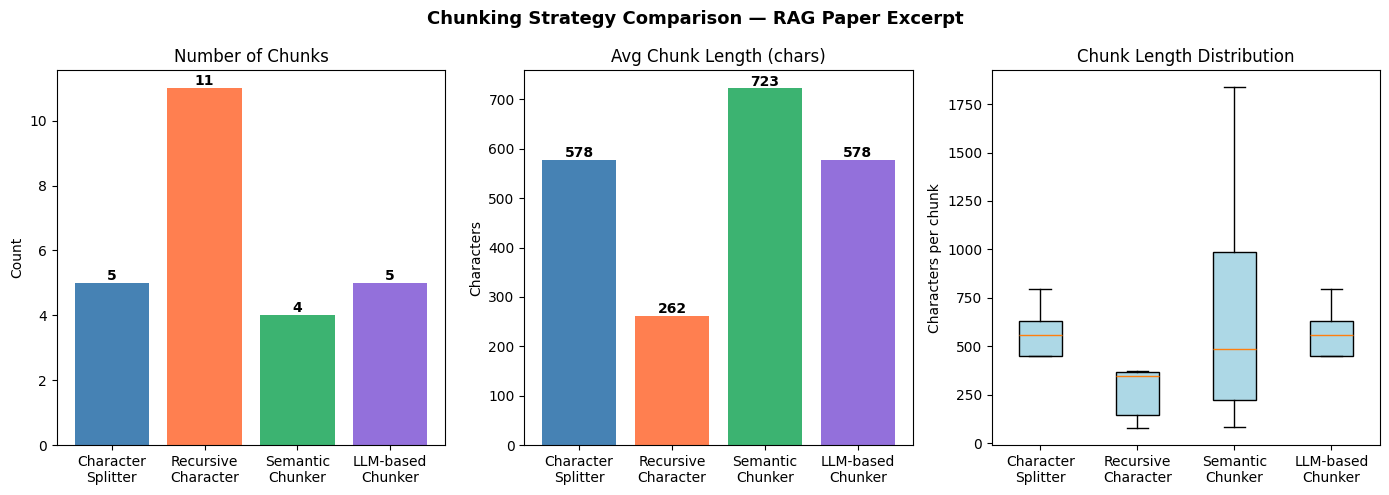

Method                 | Chunks |  Avg len |  Std dev
-------------------------------------------------------
Character Splitter     |      5 |      578 |      129
Recursive Character    |     11 |      262 |      119
Semantic Chunker       |      4 |      723 |      681
LLM-based Chunker      |      5 |      578 |      129


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Collect stats for each method
char_chunks = CharacterTextSplitter(
    separator="\n\n", chunk_size=400, chunk_overlap=60
).create_documents([rag_paper_text])

rec_chunks = RecursiveCharacterTextSplitter(
    chunk_size=400, chunk_overlap=60
).create_documents([rag_paper_text])

# semantic and stat chunks already computed above
llm_contents = [c.content for c in result.chunks]

methods = {
    "Character\nSplitter":   [len(c.page_content) for c in char_chunks],
    "Recursive\nCharacter":  [len(c.page_content) for c in rec_chunks],
    "Semantic\nChunker":     [len(c.page_content) for c in chunks_semantic],
    "LLM-based\nChunker":    [len(c) for c in llm_contents],
}

names     = list(methods.keys())
counts    = [len(v) for v in methods.values()]
avgs      = [np.mean(v) for v in methods.values()]
std_devs  = [np.std(v) for v in methods.values()]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Chart 1: number of chunks
axes[0].bar(names, counts, color=["steelblue", "coral", "mediumseagreen", "mediumpurple"])
axes[0].set_title("Number of Chunks")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontsize=10, fontweight="bold")

# Chart 2: average chunk length
axes[1].bar(names, avgs, color=["steelblue", "coral", "mediumseagreen", "mediumpurple"])
axes[1].set_title("Avg Chunk Length (chars)")
axes[1].set_ylabel("Characters")
for i, v in enumerate(avgs):
    axes[1].text(i, v + 5, f"{v:.0f}", ha="center", fontsize=10, fontweight="bold")

# Chart 3: chunk length distribution (box plot)
axes[2].boxplot(list(methods.values()), labels=names, patch_artist=True,
                boxprops=dict(facecolor="lightblue"))
axes[2].set_title("Chunk Length Distribution")
axes[2].set_ylabel("Characters per chunk")

plt.suptitle("Chunking Strategy Comparison — RAG Paper Excerpt", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Method':<22} | {'Chunks':>6} | {'Avg len':>8} | {'Std dev':>8}")
print("-" * 55)
for name, vals in methods.items():
    clean_name = name.replace("\n", " ")
    print(f"{clean_name:<22} | {len(vals):>6} | {np.mean(vals):>8.0f} | {np.std(vals):>8.0f}")

### When to Use Each Strategy

| Strategy | Best for | Cost | Coherence |
|---|---|---|---|
| **Character Splitter** | Quick prototypes, uniform text | Very low | Low |
| **Recursive Character** | General prose, markdown, code | Very low | Medium |
| **Semantic Chunker** | Mixed-topic documents, articles | Medium (embedding API) | High |
| **Statistical Semantic** | Long documents, no API cost preferred | Low (local model) | High |
| **LLM-based** | High-value documents, complex structure | High (LLM tokens) | Very high |

In practice, **Recursive Character Text Splitter** is the right default for most
RAG pipelines. Switch to semantic or LLM-based chunking when retrieval quality
on a character-split corpus is measurably poor.

## References

- [LangChain: Text Splitters](https://python.langchain.com/docs/concepts/text_splitters/)
- [LangChain: RecursiveCharacterTextSplitter](https://python.langchain.com/docs/how_to/recursive_text_splitter/)
- [LangChain: SemanticChunker](https://python.langchain.com/docs/how_to/semantic-chunker/)
- [semantic-chunkers library](https://github.com/aurelio-labs/semantic-chunkers)
- [Lewis et al. (2020) — Retrieval-Augmented Generation](https://arxiv.org/abs/2005.11401)
- [Pinecone: Chunking Strategies for LLM Applications](https://www.pinecone.io/learn/chunking-strategies/)